In [38]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt

# Train/test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [39]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Make results reproducible
RANDOM_STATE = 42

In [40]:
loan_file = r"C:\Users\anima\OneDrive - UTS\Desktop\31250 - IDA\Dataset files\Assignment3-Loan-Dataset.csv"
unknown_file = r"C:\Users\anima\OneDrive - UTS\Desktop\31250 - IDA\Dataset files\Assignment3-Unknown-Dataset.csv"
sample_file = r"C:\Users\anima\OneDrive - UTS\Desktop\31250 - IDA\Dataset files\Assignment3-Kaggle-Submission-Sample.csv"

loan_df = pd.read_csv(loan_file)
unknown_df = pd.read_csv(unknown_file)
submission_sample = pd.read_csv(sample_file)

In [41]:
loan_df.head()

,age,income,credit_score,loan_amount,debt_to_income_pct,num_dependents,years_employed,account_balance,num_prev_loans,monthly_expenses,gender,employment_status,education_level,loan_purpose,region,marital_status,application_year,loan_duration_months,application_date,loan_default
0,56,70760.04,802,11846.59,67.15,1.0,11.7,NaN,8,19630.68,Female,Self-Employed,NaN,Business,South,Married,2018,24,2018-06-23,1
1,69,31366.22,629,58014.20,21.87,NaN,5.7,2077.13,9,5329.77,Male,Part-Time,Master,Education,Central,Single,2018,36,2018-03-06,1
2,46,23374.68,608,19059.09,16.07,0.0,NaN,8815.60,2,4528.69,Female,Self-Employed,Master,Education,East,Single,2023,84,2023-05-04,0
3,32,46647.88,638,57194.52,18.88,0.0,0.8,2253.18,5,7815.41,Female,Full-Time,Master,Personal,South,Widowed,2015,12,2015-02-04,1
4,60,49864.95,647,19768.34,19.00,2.0,NaN,17106.10,6,14020.53,Male,Part-Time,High School,Education,Central,NaN,2024,60,2024-03-18,1


In [5]:
print(loan_df.dtypes)

age                       int64
income                  float64
credit_score              int64
loan_amount             float64
debt_to_income_pct      float64
num_dependents          float64
years_employed          float64
account_balance         float64
num_prev_loans            int64
monthly_expenses        float64
gender                   object
employment_status        object
education_level          object
loan_purpose             object
region                   object
marital_status           object
application_year          int64
loan_duration_months      int64
application_date         object
loan_default              int64
dtype: object


In [6]:
print("Loan dataset shape:", loan_df.shape)
print("Unknown dataset shape:", unknown_df.shape)
print("Submission sample shape:", submission_sample.shape)

print("\nLoan dataset columns:")
print(loan_df.columns)

print("\nUnknown dataset columns:")
print(unknown_df.columns)

print("\nSubmission sample columns:")
print(submission_sample.columns)

Loan dataset shape: (35000, 20)
Unknown dataset shape: (15000, 19)
Submission sample shape: (15000, 2)

Loan dataset columns:
Index(['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct',
       'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans',
       'monthly_expenses', 'gender', 'employment_status', 'education_level',
       'loan_purpose', 'region', 'marital_status', 'application_year',
       'loan_duration_months', 'application_date', 'loan_default'],
      dtype='object')

Unknown dataset columns:
Index(['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct',
       'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans',
       'monthly_expenses', 'gender', 'employment_status', 'education_level',
       'loan_purpose', 'region', 'marital_status', 'application_year',
       'loan_duration_months', 'application_date'],
      dtype='object')

Submission sample columns:
Index(['row ID', 'Predicted-Loan-Default'], dt

In [42]:
#Data Exploration
loan_df.info()
loan_df.describe()
loan_df.describe(include="object")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   35000 non-null  int64  
 1   income                32903 non-null  float64
 2   credit_score          35000 non-null  int64  
 3   loan_amount           35000 non-null  float64
 4   debt_to_income_pct    35000 non-null  float64
 5   num_dependents        33190 non-null  float64
 6   years_employed        32296 non-null  float64
 7   account_balance       32570 non-null  float64
 8   num_prev_loans        35000 non-null  int64  
 9   monthly_expenses      31741 non-null  float64
 10  gender                35000 non-null  object 
 11  employment_status     35000 non-null  object 
 12  education_level       29272 non-null  object 
 13  loan_purpose          35000 non-null  object 
 14  region                35000 non-null  object 
 15  marital_status     

,gender,employment_status,education_level,loan_purpose,region,marital_status,application_date
count,35000,35000,29272,35000,35000,30784,35000
unique,3,5,4,6,5,4,5021
top,Male,Full-Time,Bachelor,Home,Central,Married,2016-01-28
freq,17214,17385,10973,8780,7172,13929,20


In [43]:
missing_counts = loan_df.isna().sum()
missing_percent = loan_df.isna().mean()*100

missing_table = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent": missing_percent
}).sort_values(by="Missing Percent", ascending=False)

missing_table

,Missing Count,Missing Percent
education_level,5728,16.365714
marital_status,4216,12.045714
monthly_expenses,3259,9.311429
years_employed,2704,7.725714
account_balance,2430,6.942857
income,2097,5.991429
num_dependents,1810,5.171429
age,0,0.000000
loan_purpose,0,0.000000
application_date,0,0.000000


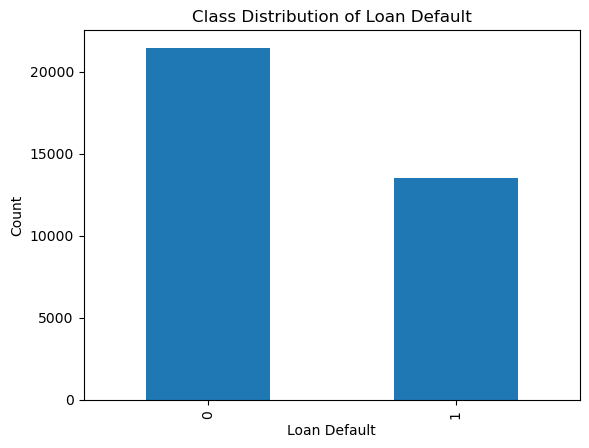

In [44]:
loan_df["loan_default"].value_counts()
loan_df["loan_default"].value_counts(normalize=True) * 100

loan_df["loan_default"].value_counts().plot(kind="bar")
plt.title("Class Distribution of Loan Default")
plt.xlabel("Loan Default")
plt.ylabel("Count")
plt.show()

In [45]:
target_col = "loan_default"

X = loan_df.drop(columns=[target_col])
y = loan_df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (35000, 19)
y shape: (35000,)


In [46]:
X = X.drop(columns=["application_date"])
unknown_X = unknown_df.drop(columns=["application_date"])

print("X columns:", X.columns)
print("Unknown columns:", unknown_X.columns)

X columns: Index(['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct',
       'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans',
       'monthly_expenses', 'gender', 'employment_status', 'education_level',
       'loan_purpose', 'region', 'marital_status', 'application_year',
       'loan_duration_months'],
      dtype='object')
Unknown columns: Index(['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct',
       'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans',
       'monthly_expenses', 'gender', 'employment_status', 'education_level',
       'loan_purpose', 'region', 'marital_status', 'application_year',
       'loan_duration_months'],
      dtype='object')


In [47]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct', 'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans', 'monthly_expenses', 'application_year', 'loan_duration_months']

Categorical features:
['gender', 'employment_status', 'education_level', 'loan_purpose', 'region', 'marital_status']


In [48]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [49]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (24500, 18)
X_valid: (10500, 18)
y_train: (24500,)
y_valid: (10500,)


In [50]:
def evaluate_model(model, X_train, y_train, X_valid, y_valid, model_name):
    """
    Trains are already fitted before calling this function.
    This function prints training and validation performance.
    """

    # Predictions
    y_train_pred = model.predict(X_train)
    y_valid_pred = model.predict(X_valid)

    # Probabilities for AUC
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_valid_proba = model.predict_proba(X_valid)[:, 1]

    # Confusion matrix values for validation
    tn, fp, fn, tp = confusion_matrix(y_valid, y_valid_pred).ravel()

    # Metrics
    results = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Valid Accuracy": accuracy_score(y_valid, y_valid_pred),
        "Valid Precision": precision_score(y_valid, y_valid_pred, zero_division=0),
        "Valid Recall/Sensitivity": recall_score(y_valid, y_valid_pred, zero_division=0),
        "Valid Specificity": tn / (tn + fp),
        "Valid F1": f1_score(y_valid, y_valid_pred, zero_division=0),
        "Valid AUC": roc_auc_score(y_valid, y_valid_proba)
    }

    print(f"===== {model_name} =====")
    print("\nTraining classification report:")
    print(classification_report(y_train, y_train_pred, zero_division=0))

    print("\nValidation classification report:")
    print(classification_report(y_valid, y_valid_pred, zero_division=0))

    print("\nValidation confusion matrix:")
    print(confusion_matrix(y_valid, y_valid_pred))

    return results

## Decision Tree Model


In [16]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",
        max_depth=5,
        min_samples_leaf=20,
        random_state=RANDOM_STATE
    ))
])

dt_model.fit(X_train, y_train)

dt_results = evaluate_model(
    dt_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Decision Tree"
)

dt_results

===== Decision Tree =====

Training classification report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.84     15027
           1       0.78      0.61      0.69      9473

    accuracy                           0.79     24500
   macro avg       0.79      0.75      0.76     24500
weighted avg       0.79      0.79      0.78     24500


Validation classification report:
              precision    recall  f1-score   support

           0       0.77      0.89      0.83      6440
           1       0.77      0.59      0.67      4060

    accuracy                           0.77     10500
   macro avg       0.77      0.74      0.75     10500
weighted avg       0.77      0.77      0.77     10500


Validation confusion matrix:
[[5716  724]
 [1667 2393]]


{'Model': 'Decision Tree',
 'Train Accuracy': 0.7853877551020408,
 'Valid Accuracy': 0.7722857142857142,
 'Valid Precision': 0.7677253769650305,
 'Valid Recall/Sensitivity': 0.5894088669950739,
 'Valid Specificity': np.float64(0.8875776397515528),
 'Valid F1': 0.6668524453114114,
 'Valid AUC': 0.8111128683107426}

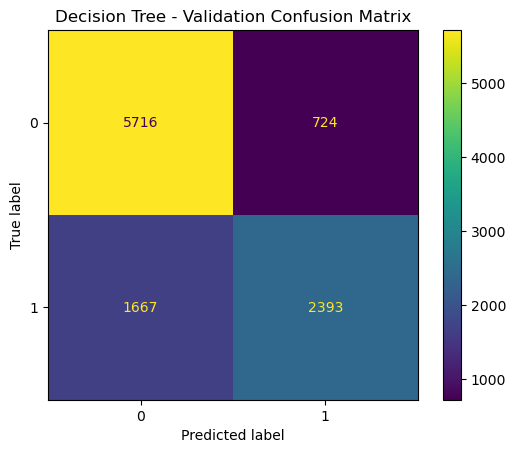

In [17]:
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_valid,
    y_valid
)

plt.title("Decision Tree - Validation Confusion Matrix")
plt.show()

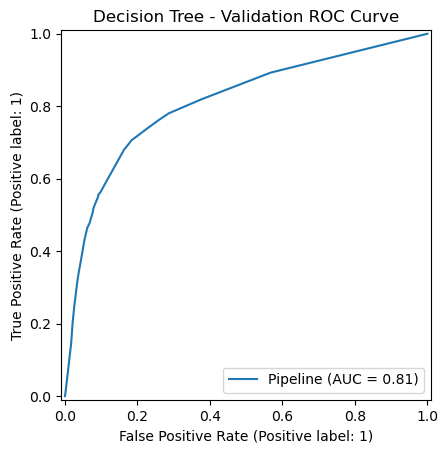

In [18]:
RocCurveDisplay.from_estimator(
    dt_model,
    X_valid,
    y_valid
)

plt.title("Decision Tree - Validation ROC Curve")
plt.show()

In [17]:
pd.DataFrame([dt_results])

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,Decision Tree,0.785388,0.772286,0.767725,0.589409,0.887578,0.666852,0.811113


## K-Nearest Neighbour Model

In [24]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform"
    ))
])

knn_model.fit(X_train, y_train)

knn_results = evaluate_model(
    knn_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "KNN"
)

knn_results

===== KNN =====

Training classification report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85     15027
           1       0.80      0.65      0.72      9473

    accuracy                           0.80     24500
   macro avg       0.80      0.77      0.78     24500
weighted avg       0.80      0.80      0.80     24500


Validation classification report:
              precision    recall  f1-score   support

           0       0.72      0.84      0.78      6440
           1       0.66      0.49      0.56      4060

    accuracy                           0.71     10500
   macro avg       0.69      0.67      0.67     10500
weighted avg       0.70      0.71      0.70     10500


Validation confusion matrix:
[[5440 1000]
 [2084 1976]]


{'Model': 'KNN',
 'Train Accuracy': 0.8023673469387755,
 'Valid Accuracy': 0.7062857142857143,
 'Valid Precision': 0.6639784946236559,
 'Valid Recall/Sensitivity': 0.48669950738916257,
 'Valid Specificity': np.float64(0.84472049689441),
 'Valid F1': 0.5616827743035816,
 'Valid AUC': 0.7218183765260227}

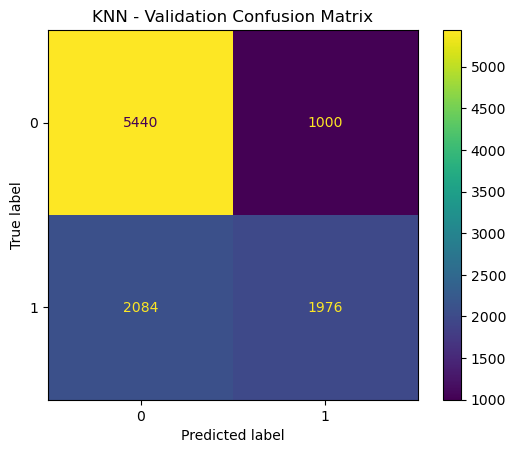

In [25]:
ConfusionMatrixDisplay.from_estimator(
    knn_model,
    X_valid,
    y_valid
)

plt.title("KNN - Validation Confusion Matrix")
plt.show()

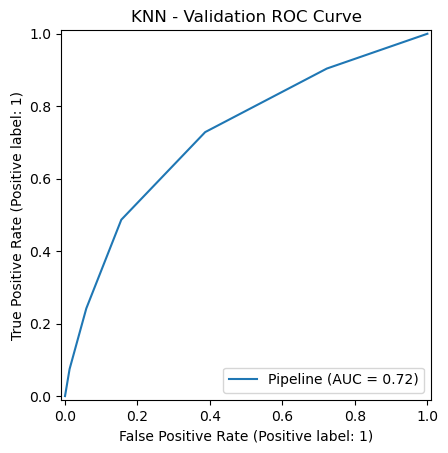

In [26]:
RocCurveDisplay.from_estimator(
    knn_model,
    X_valid,
    y_valid
)

plt.title("KNN - Validation ROC Curve")
plt.show()

In [27]:
pd.DataFrame([knn_results])

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,KNN,0.802367,0.706286,0.663978,0.4867,0.84472,0.561683,0.721818


In [21]:
#testing different parameter settings 
knn_param_results = []

for k in [3, 5, 7, 9, 11, 15, 21]:
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=k,
            weights="uniform"
        ))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_valid)
    y_proba = model.predict_proba(X_valid)[:, 1]
    
    knn_param_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred, zero_division=0),
        "Recall": recall_score(y_valid, y_pred, zero_division=0),
        "F1": f1_score(y_valid, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_valid, y_proba)
    })

knn_param_df = pd.DataFrame(knn_param_results)
knn_param_df

,k,Accuracy,Precision,Recall,F1,AUC
0,3,0.687714,0.619310,0.499261,0.552843,0.692764
1,5,0.706286,0.663978,0.486700,0.561683,0.721818
2,7,0.715238,0.687194,0.483744,0.567794,0.743411
3,9,0.719048,0.700506,0.477586,0.567955,0.754084
4,11,0.722381,0.714500,0.469704,0.566800,0.762841
5,15,0.730762,0.740351,0.467734,0.573283,0.776652
6,21,0.732667,0.750901,0.461823,0.571908,0.786949


In [22]:
knn_param_df.sort_values(by="AUC", ascending=False)
best_k = knn_param_df.sort_values(by="AUC", ascending=False).iloc[0]["k"]
best_k

np.float64(21.0)

In [23]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=int(best_k),
        weights="uniform"
    ))
])

## Random Forest Model

In [19]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=10,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Random Forest"
)

rf_results

===== Random Forest =====

Training classification report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     15027
           1       0.81      0.81      0.81      9473

    accuracy                           0.86     24500
   macro avg       0.85      0.85      0.85     24500
weighted avg       0.86      0.86      0.86     24500


Validation classification report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      6440
           1       0.76      0.77      0.76      4060

    accuracy                           0.82     10500
   macro avg       0.81      0.81      0.81     10500
weighted avg       0.82      0.82      0.82     10500


Validation confusion matrix:
[[5459  981]
 [ 946 3114]]


{'Model': 'Random Forest',
 'Train Accuracy': 0.8552244897959184,
 'Valid Accuracy': 0.8164761904761905,
 'Valid Precision': 0.7604395604395604,
 'Valid Recall/Sensitivity': 0.7669950738916256,
 'Valid Specificity': np.float64(0.8476708074534162),
 'Valid F1': 0.7637032495401594,
 'Valid AUC': 0.8498059388673009}

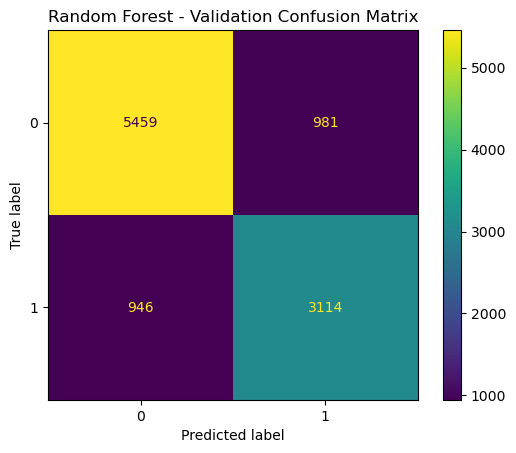

In [20]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_valid,
    y_valid
)

plt.title("Random Forest - Validation Confusion Matrix")
plt.show()

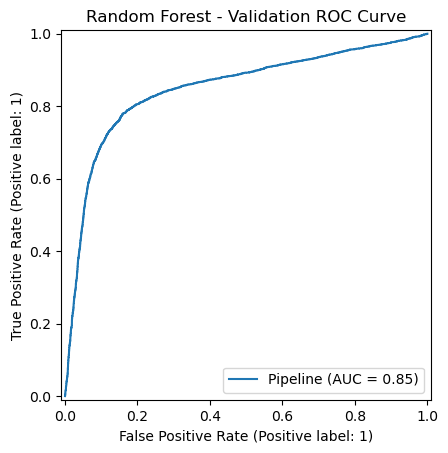

In [21]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_valid,
    y_valid
)

plt.title("Random Forest - Validation ROC Curve")
plt.show()

In [22]:
pd.DataFrame([rf_results])

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,Random Forest,0.855224,0.816476,0.76044,0.766995,0.847671,0.763703,0.849806


## Support Vector Machine Model 

In [29]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            max_iter=5000
        )
    ))
])

svm_model.fit(X_train, y_train)

svm_results = evaluate_model(
    svm_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Support Vector Machine"
)

svm_results

===== Support Vector Machine =====

Training classification report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82     15027
           1       0.74      0.61      0.67      9473

    accuracy                           0.77     24500
   macro avg       0.76      0.74      0.74     24500
weighted avg       0.76      0.77      0.76     24500


Validation classification report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81      6440
           1       0.73      0.60      0.66      4060

    accuracy                           0.76     10500
   macro avg       0.75      0.73      0.74     10500
weighted avg       0.76      0.76      0.75     10500


Validation confusion matrix:
[[5547  893]
 [1628 2432]]


{'Model': 'Support Vector Machine',
 'Train Accuracy': 0.7666530612244898,
 'Valid Accuracy': 0.7599047619047619,
 'Valid Precision': 0.7314285714285714,
 'Valid Recall/Sensitivity': 0.5990147783251232,
 'Valid Specificity': np.float64(0.861335403726708),
 'Valid F1': 0.6586323628977657,
 'Valid AUC': 0.8000169048128997}

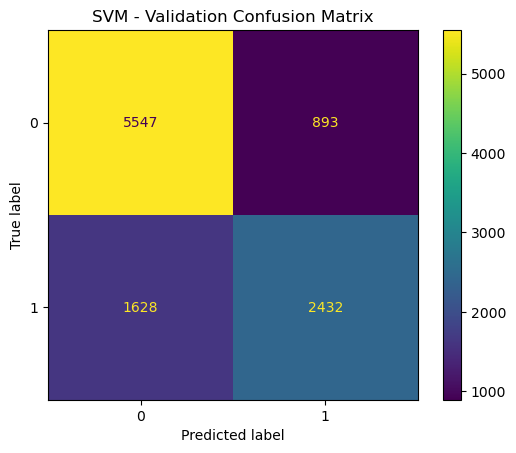

In [30]:
ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_valid,
    y_valid
)

plt.title("SVM - Validation Confusion Matrix")
plt.show()

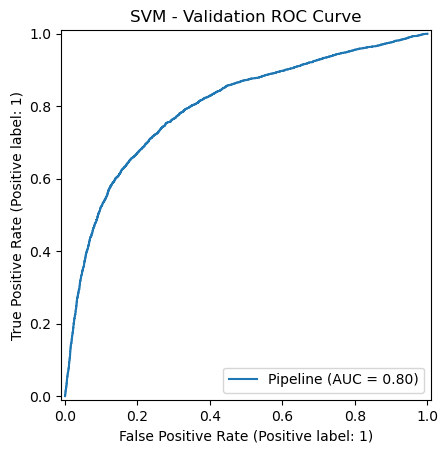

In [31]:
RocCurveDisplay.from_estimator(
    svm_model,
    X_valid,
    y_valid
)

plt.title("SVM - Validation ROC Curve")
plt.show()

In [32]:
pd.DataFrame([svm_results])

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,Support Vector Machine,0.766653,0.759905,0.731429,0.599015,0.861335,0.658632,0.800017


## Neural Network Model

In [51]:
nn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", MLPClassifier(
        hidden_layer_sizes=(20, 10),
        activation="relu",
        solver="adam",
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True
    ))
])

nn_model.fit(X_train, y_train)

nn_results = evaluate_model(
    nn_model,
    X_train,
    y_train,
    X_valid,
    y_valid,
    "Neural Network"
)

nn_results

===== Neural Network =====

Training classification report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84     15027
           1       0.79      0.65      0.71      9473

    accuracy                           0.80     24500
   macro avg       0.80      0.77      0.78     24500
weighted avg       0.80      0.80      0.79     24500


Validation classification report:
              precision    recall  f1-score   support

           0       0.79      0.89      0.83      6440
           1       0.77      0.62      0.69      4060

    accuracy                           0.78     10500
   macro avg       0.78      0.75      0.76     10500
weighted avg       0.78      0.78      0.78     10500


Validation confusion matrix:
[[5702  738]
 [1525 2535]]


{'Model': 'Neural Network',
 'Train Accuracy': 0.7985714285714286,
 'Valid Accuracy': 0.7844761904761904,
 'Valid Precision': 0.7745187901008249,
 'Valid Recall/Sensitivity': 0.624384236453202,
 'Valid Specificity': np.float64(0.8854037267080745),
 'Valid F1': 0.6913950634119733,
 'Valid AUC': 0.8276338233944251}

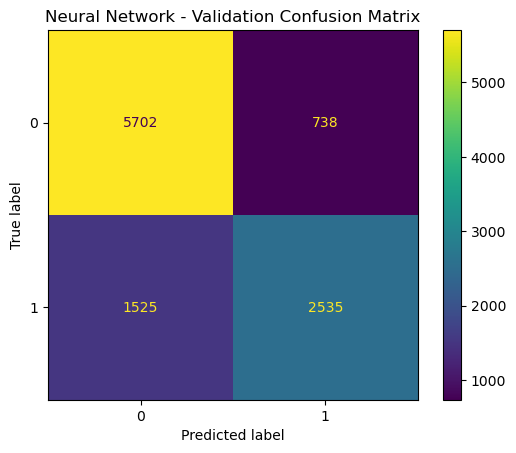

In [52]:
ConfusionMatrixDisplay.from_estimator(
    nn_model,
    X_valid,
    y_valid
)

plt.title("Neural Network - Validation Confusion Matrix")
plt.show()

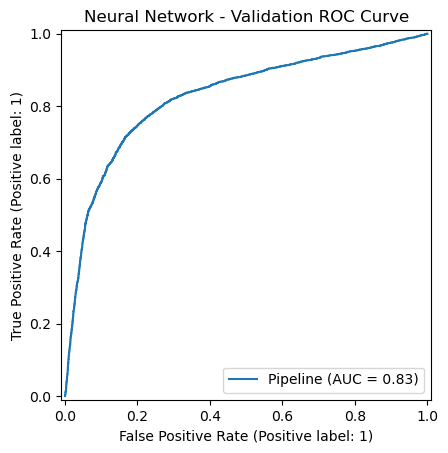

In [53]:
RocCurveDisplay.from_estimator(
    nn_model,
    X_valid,
    y_valid
)

plt.title("Neural Network - Validation ROC Curve")
plt.show()

In [54]:
pd.DataFrame([nn_results])

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,Neural Network,0.798571,0.784476,0.774519,0.624384,0.885404,0.691395,0.827634


## Summary Table for all model results

In [33]:
results_df = pd.DataFrame([
    dt_results,
    knn_results,
    rf_results,
    svm_results,
    nn_results
])

results_df

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
0,Decision Tree,0.785388,0.772286,0.767725,0.589409,0.887578,0.666852,0.811113
1,KNN,0.802367,0.706286,0.663978,0.486700,0.844720,0.561683,0.721818
2,Random Forest,0.855224,0.816476,0.760440,0.766995,0.847671,0.763703,0.849806
3,Support Vector Machine,0.766653,0.759905,0.731429,0.599015,0.861335,0.658632,0.800017
4,Neural Network,0.798571,0.784476,0.774519,0.624384,0.885404,0.691395,0.827634


In [34]:
results_df.sort_values(by="Valid F1", ascending=False)

,Model,Train Accuracy,Valid Accuracy,Valid Precision,Valid Recall/Sensitivity,Valid Specificity,Valid F1,Valid AUC
2,Random Forest,0.855224,0.816476,0.760440,0.766995,0.847671,0.763703,0.849806
4,Neural Network,0.798571,0.784476,0.774519,0.624384,0.885404,0.691395,0.827634
0,Decision Tree,0.785388,0.772286,0.767725,0.589409,0.887578,0.666852,0.811113
3,Support Vector Machine,0.766653,0.759905,0.731429,0.599015,0.861335,0.658632,0.800017
1,KNN,0.802367,0.706286,0.663978,0.486700,0.844720,0.561683,0.721818


In [36]:
dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
svm_model.fit(X_train, y_train)
nn_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
from sklearn.utils.validation import check_is_fitted
from sklearn.exceptions import NotFittedError

models = {
    "DT": dt_model,
    "KNN": knn_model,
    "RF": rf_model,
    "SVM": svm_model,
    "NN": nn_model
}

for model_name, model in models.items():
    try:
        check_is_fitted(model)
        print(model_name, "is fitted")
    except NotFittedError:
        print(model_name, "is NOT fitted")

DT is fitted
KNN is fitted
RF is fitted
SVM is fitted
NN is fitted


In [38]:
models = {
    "DT": dt_model,
    "KNN": knn_model,
    "RF": rf_model,
    "SVM": svm_model,
    "NN": nn_model
}

for model_name, model in models.items():
    # Predict unknown dataset
    predictions = model.predict(unknown_X)

    # Create Kaggle submission file
    submission = pd.DataFrame({
        "row ID": submission_sample["row ID"],
        "Predicted-Loan-Default": predictions
    })

    # Check submission
    print("Model:", model_name)
    print("Missing values:")
    print(submission.isna().sum())
    print("Submission shape:", submission.shape)
    print(submission.head())

    # Save CSV
    filename = f"ida_a3_26074334_{model_name}.csv"
    submission.to_csv(filename, index=False)
    print("Saved:", filename)
    print("-" * 50)

Model: DT
Missing values:
row ID                    0
Predicted-Loan-Default    0
dtype: int64
Submission shape: (15000, 2)
  row ID  Predicted-Loan-Default
0   Row0                       0
1   Row1                       0
2   Row2                       1
3   Row3                       1
4   Row4                       1
Saved: ida_a3_26074334_DT.csv
--------------------------------------------------
Model: KNN
Missing values:
row ID                    0
Predicted-Loan-Default    0
dtype: int64
Submission shape: (15000, 2)
  row ID  Predicted-Loan-Default
0   Row0                       0
1   Row1                       0
2   Row2                       1
3   Row3                       1
4   Row4                       1
Saved: ida_a3_26074334_KNN.csv
--------------------------------------------------
Model: RF
Missing values:
row ID                    0
Predicted-Loan-Default    0
dtype: int64
Submission shape: (15000, 2)
  row ID  Predicted-Loan-Default
0   Row0                       0
1 